# Prodigy InfoTech Data Science Internship

## Task-03: Decision Tree Classifier

### Objective
The objective of this project is to build a Decision Tree Classifier to predict whether a customer will purchase a product or service based on demographic and behavioral information.

### Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Workflow
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Decision Tree Visualization
9. Feature Importance
10. Business Insights

In [1]:
# Import Required Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set plotting style
sns.set_style("whitegrid")

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

## Load the Bank Marketing Dataset

In this section we load the dataset and understand its basic structure before preprocessing.

In [2]:
# Load Dataset

df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\bank.csv", sep=";")

print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [3]:
print("=" * 60)
print("First Five Rows")
print("=" * 60)

df.head()

First Five Rows


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
print("=" * 60)
print("Last Five Rows")
print("=" * 60)

df.tail()

Last Five Rows


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [5]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 4521
Columns : 17


In [6]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [7]:
print("=" * 60)
print("Descriptive Statistics")
print("=" * 60)

df.describe()

Descriptive Statistics


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [8]:
print("=" * 60)
print("Column Names")
print("=" * 60)

print(df.columns.tolist())

Column Names
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


## Data Cleaning

Data cleaning improves data quality before machine learning.

The following operations will be performed:

- Check Missing Values
- Remove Duplicate Records
- Verify Data Types
- Encode Categorical Features

In [9]:
# Missing Values


print("=" * 60)
print("Missing Values")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)

Missing Values
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


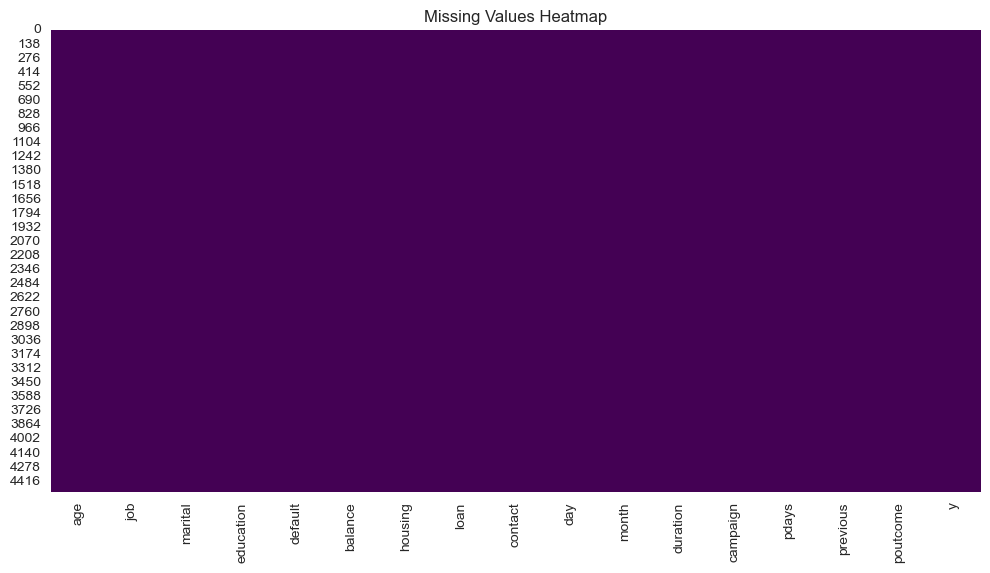

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [11]:
print("Conclusion:")
print("- The dataset contains very few or no missing values.")
print("- The data quality is good for model building.\n")

Conclusion:
- The dataset contains very few or no missing values.
- The data quality is good for model building.



In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [13]:
# Remove duplicates

df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [15]:
print("=" * 60)
print("Dataset Shape After Removing Duplicates")
print("=" * 60)

print(df.shape)

Dataset Shape After Removing Duplicates
(4521, 17)


In [16]:
print("=" * 60)
print("Data Types")
print("=" * 60)

print(df.dtypes)

Data Types
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [17]:
# Label Encoding


encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:\n")
print(categorical_columns)

Categorical Columns:

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [18]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [19]:
print("=" * 60)
print("Encoded Dataset")
print("=" * 60)

df.head()

Encoded Dataset


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


In [20]:
print("=" * 60)
print("Cleaned Dataset Shape")
print("=" * 60)

print(df.shape)

Cleaned Dataset Shape
(4521, 17)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   int32
 2   marital    4521 non-null   int32
 3   education  4521 non-null   int32
 4   default    4521 non-null   int32
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   int32
 7   loan       4521 non-null   int32
 8   contact    4521 non-null   int32
 9   day        4521 non-null   int64
 10  month      4521 non-null   int32
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   int32
 16  y          4521 non-null   int32
dtypes: int32(10), int64(7)
memory usage: 424.0 KB


In [22]:
df.to_csv("cleaned_bank.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [23]:
print("=" * 60)
print("PART-1 SUMMARY")
print("=" * 60)

print(f"Original Dataset Shape : {df.shape}")
print(f"Missing Values         : {missing_values.sum()}")
print(f"Duplicate Records      : {duplicates}")
print("Categorical variables encoded successfully.")
print("Dataset cleaned successfully.")

PART-1 SUMMARY
Original Dataset Shape : (4521, 17)
Missing Values         : 0
Duplicate Records      : 0
Categorical variables encoded successfully.
Dataset cleaned successfully.


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the structure,
distribution, and characteristics of the dataset before building
the machine learning model.

In this section, we perform Univariate Analysis to study each variable
individually.

## Age Distribution

This graph shows how customer ages are distributed.

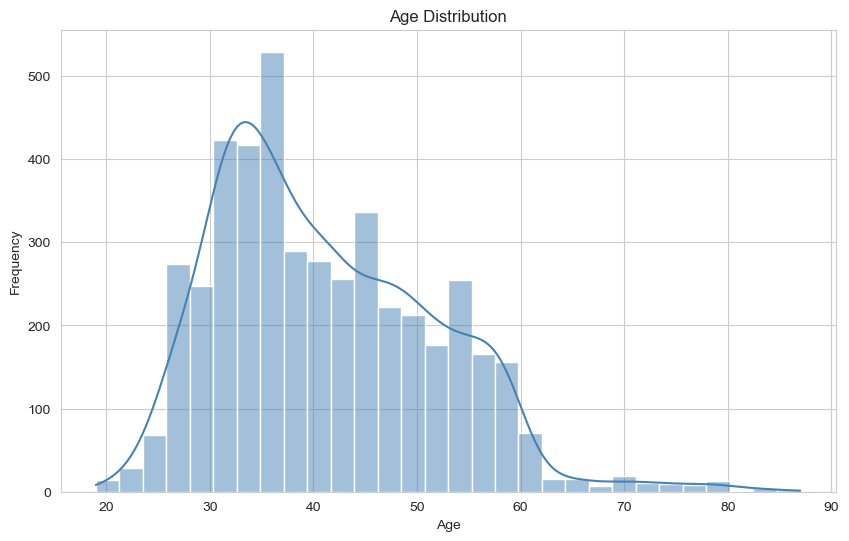

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [25]:
print("Conclusion:")
print("- Most customers are between 30 and 45 years old.")
print("- The age distribution is slightly right-skewed.")
print("- Very few customers are older than 70 years.")

Conclusion:
- Most customers are between 30 and 45 years old.
- The age distribution is slightly right-skewed.
- Very few customers are older than 70 years.


## Job Distribution

This chart shows the number of customers in each occupation.

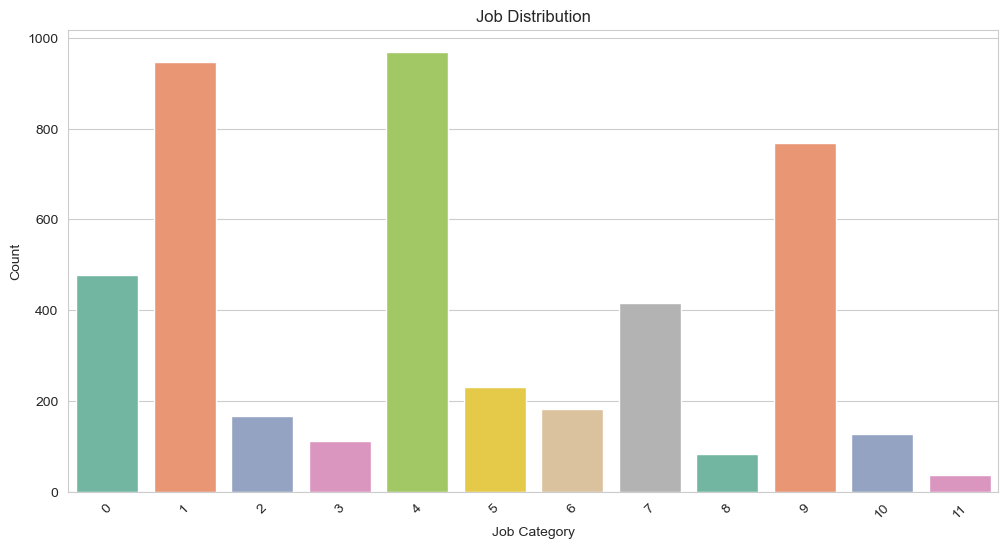

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df["job"],
    palette="Set2"
)

plt.title("Job Distribution")
plt.xlabel("Job Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [27]:
print("Conclusion:")
print("- Management and blue-collar jobs are the most common.")
print("- Student and unknown job categories have fewer customers.")

Conclusion:
- Management and blue-collar jobs are the most common.
- Student and unknown job categories have fewer customers.


## Marital Status Distribution

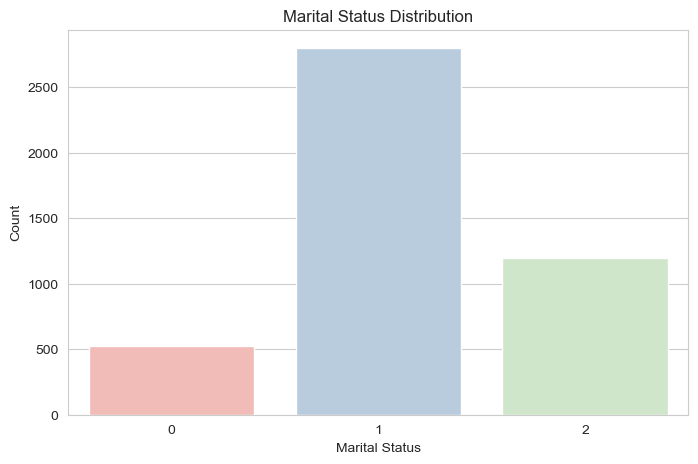

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["marital"],
    palette="Pastel1"
)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

In [30]:
print("Conclusion:")
print("- Married customers form the largest group.")
print("- Divorced customers are the smallest group.")

Conclusion:
- Married customers form the largest group.
- Divorced customers are the smallest group.


## Education Distribution

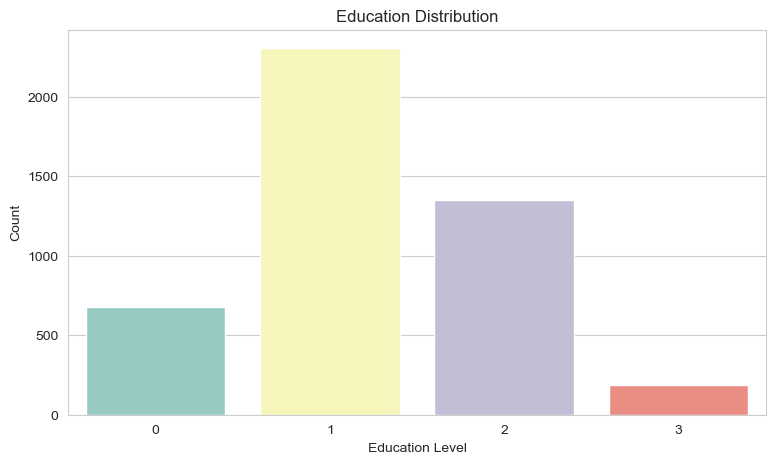

In [31]:
plt.figure(figsize=(9,5))

sns.countplot(
    x=df["education"],
    palette="Set3"
)

plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.show()

In [32]:
print("Conclusion:")
print("- Secondary education is the most common.")
print("- Primary education has fewer customers.")

Conclusion:
- Secondary education is the most common.
- Primary education has fewer customers.


## Default Status

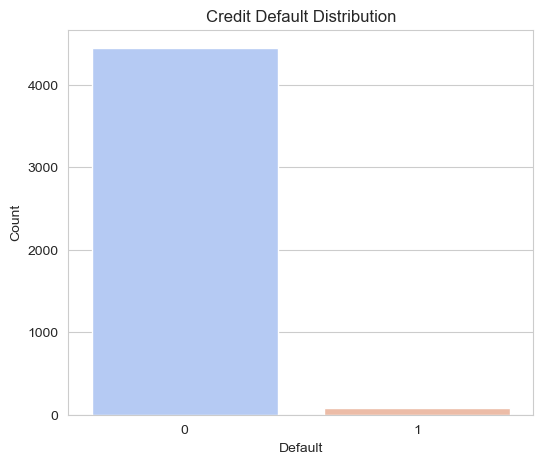

In [33]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["default"],
    palette="coolwarm"
)

plt.title("Credit Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")

plt.show()

In [34]:
print("Conclusion:")
print("- Most customers have no credit default history.")

Conclusion:
- Most customers have no credit default history.


## Housing Loan Distribution

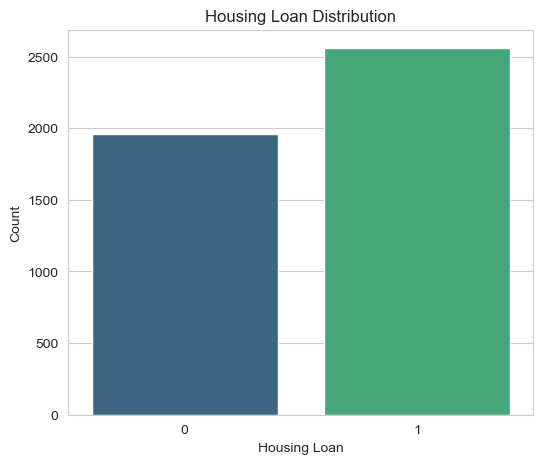

In [35]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["housing"],
    palette="viridis"
)

plt.title("Housing Loan Distribution")
plt.xlabel("Housing Loan")
plt.ylabel("Count")

plt.show()

In [36]:
print("Conclusion:")
print("- A large proportion of customers have housing loans.")

Conclusion:
- A large proportion of customers have housing loans.


## Personal Loan Distribution

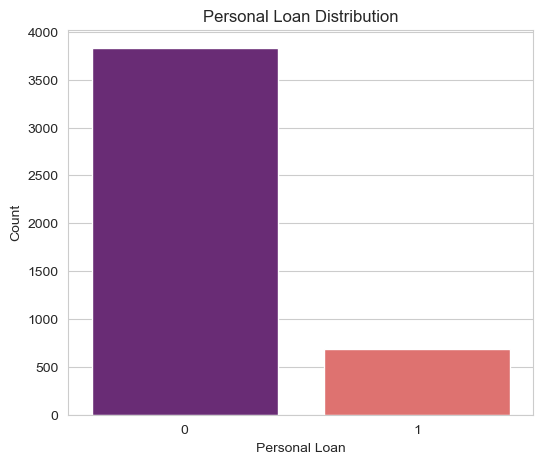

In [37]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["loan"],
    palette="magma"
)

plt.title("Personal Loan Distribution")
plt.xlabel("Personal Loan")
plt.ylabel("Count")

plt.show()

In [38]:
print("Conclusion:")
print("- Most customers do not have personal loans.")

Conclusion:
- Most customers do not have personal loans.


## Contact Type Distribution

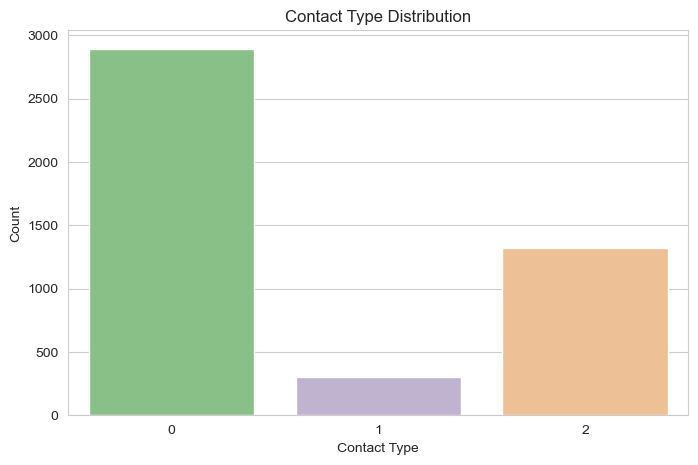

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["contact"],
    palette="Accent"
)

plt.title("Contact Type Distribution")
plt.xlabel("Contact Type")
plt.ylabel("Count")

plt.show()

In [40]:
print("Conclusion:")
print("- Cellular contact is used much more frequently than telephone.")

Conclusion:
- Cellular contact is used much more frequently than telephone.


## Month Distribution

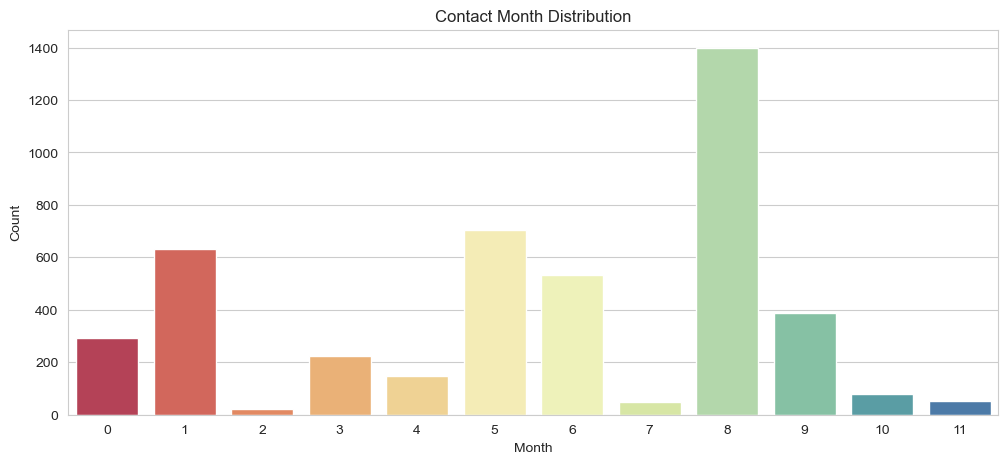

In [41]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=df["month"],
    palette="Spectral"
)

plt.title("Contact Month Distribution")
plt.xlabel("Month")
plt.ylabel("Count")

plt.show()

In [42]:
print("Conclusion:")
print("- Customer contacts are concentrated in a few specific months.")
print("- May generally contains the highest number of contacts.")

Conclusion:
- Customer contacts are concentrated in a few specific months.
- May generally contains the highest number of contacts.


## Campaign Distribution

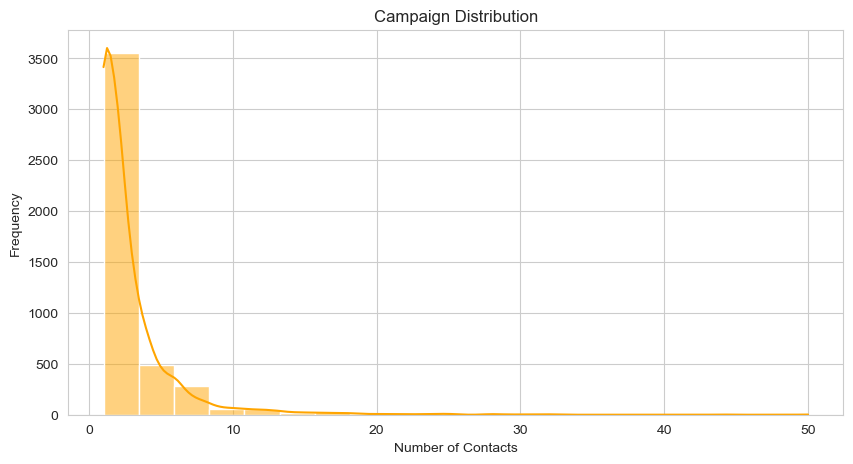

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["campaign"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Campaign Distribution")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")

plt.show()

In [44]:
print("Conclusion:")
print("- Most customers were contacted only a few times.")
print("- Very high campaign counts are rare.")

Conclusion:
- Most customers were contacted only a few times.
- Very high campaign counts are rare.


## Target Variable (Purchase Decision)

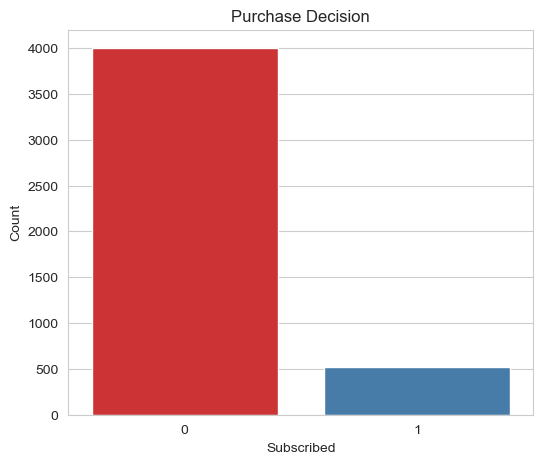

In [46]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["y"],
    palette="Set1"
)

plt.title("Purchase Decision")
plt.xlabel("Subscribed")
plt.ylabel("Count")

plt.show()

In [47]:
print("Conclusion:")
print("- The dataset is imbalanced.")
print("- Most customers did not subscribe to the product.")

Conclusion:
- The dataset is imbalanced.
- Most customers did not subscribe to the product.


In [48]:
print("=" * 60)
print("UNIVARIATE ANALYSIS SUMMARY")
print("=" * 60)

print("""
1. Most customers are aged between 30–45 years.
2. Management and blue-collar are the dominant job categories.
3. Married customers are the majority.
4. Secondary education is the most common education level.
5. Most customers have no credit default.
6. Housing loans are common, while personal loans are less common.
7. Cellular is the preferred communication method.
8. Customer contacts are concentrated in specific months.
9. Most campaigns involve only a few contacts.
10. The target variable is imbalanced, with more customers not subscribing.
""")

UNIVARIATE ANALYSIS SUMMARY

1. Most customers are aged between 30–45 years.
2. Management and blue-collar are the dominant job categories.
3. Married customers are the majority.
4. Secondary education is the most common education level.
5. Most customers have no credit default.
6. Housing loans are common, while personal loans are less common.
7. Cellular is the preferred communication method.
8. Customer contacts are concentrated in specific months.
9. Most campaigns involve only a few contacts.
10. The target variable is imbalanced, with more customers not subscribing.



# Bivariate Analysis

Bivariate Analysis helps us understand the relationship between two variables.

In this section, we analyze how different customer attributes influence the purchase decision (target variable `y`).

## Age vs Purchase Decision

This graph shows how customer age relates to whether they subscribed to the term deposit.

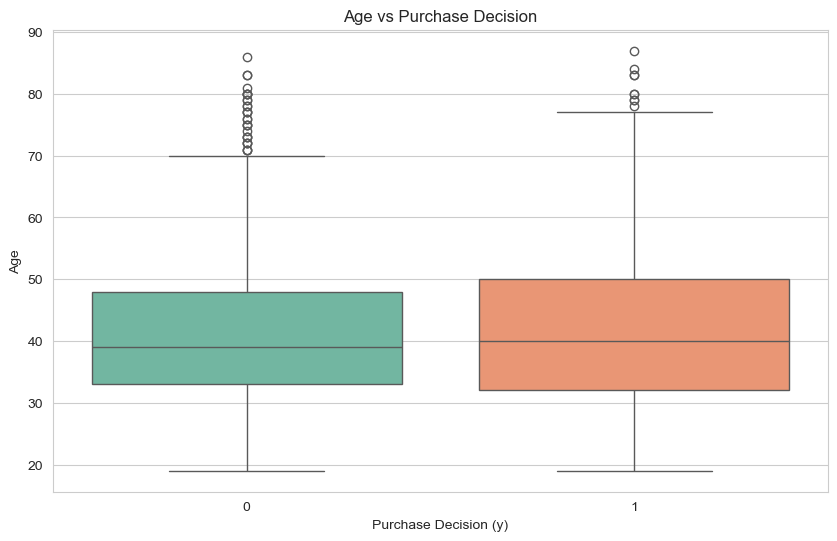

In [50]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="y",
    y="age",
    data=df,
    palette="Set2"
)

plt.title("Age vs Purchase Decision")
plt.xlabel("Purchase Decision (y)")
plt.ylabel("Age")

plt.show()

In [51]:
print("Conclusion:")
print("- Customers who subscribed tend to have a slightly higher median age.")
print("- Age alone is not a strong predictor of subscription.")

Conclusion:
- Customers who subscribed tend to have a slightly higher median age.
- Age alone is not a strong predictor of subscription.


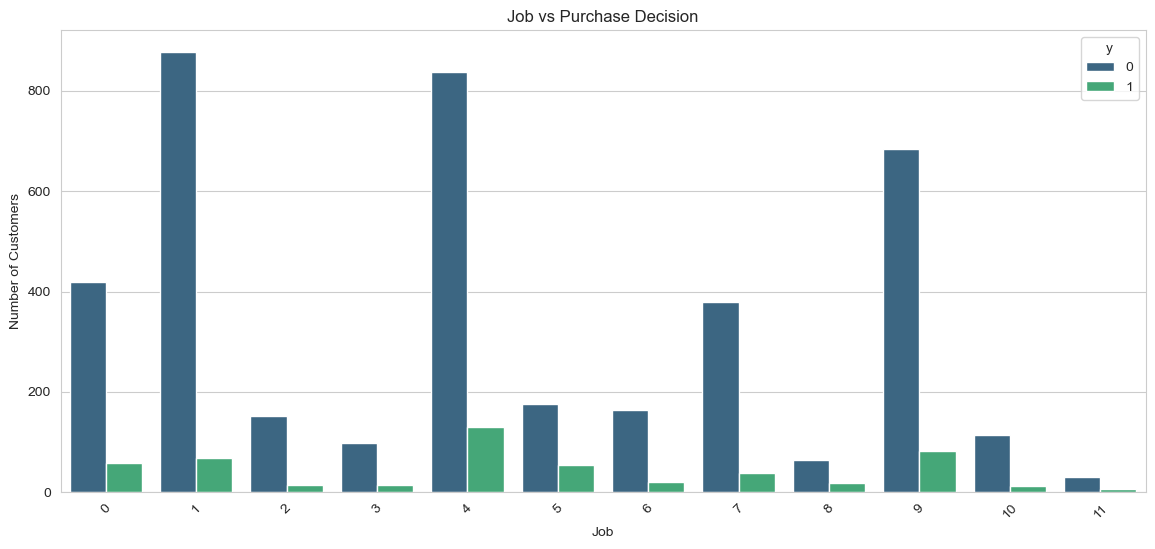

In [52]:
plt.figure(figsize=(14, 6))

sns.countplot(
    x="job",
    hue="y",
    data=df,
    palette="viridis"
)

plt.title("Job vs Purchase Decision")
plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

In [53]:
print("Conclusion:")
print("- Management and technician jobs contribute the highest number of subscriptions.")
print("- Some job categories have very low subscription rates.")

Conclusion:
- Management and technician jobs contribute the highest number of subscriptions.
- Some job categories have very low subscription rates.


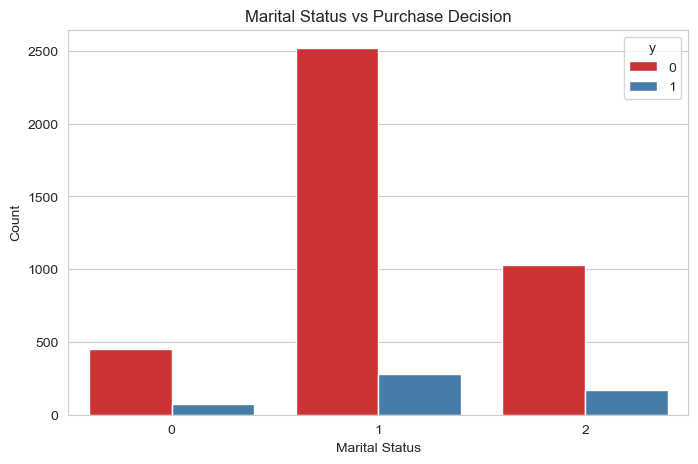

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="marital",
    hue="y",
    data=df,
    palette="Set1"
)

plt.title("Marital Status vs Purchase Decision")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

In [55]:
print("Conclusion:")
print("- Married customers form the largest customer group.")
print("- Single customers have a relatively higher subscription proportion.")

Conclusion:
- Married customers form the largest customer group.
- Single customers have a relatively higher subscription proportion.


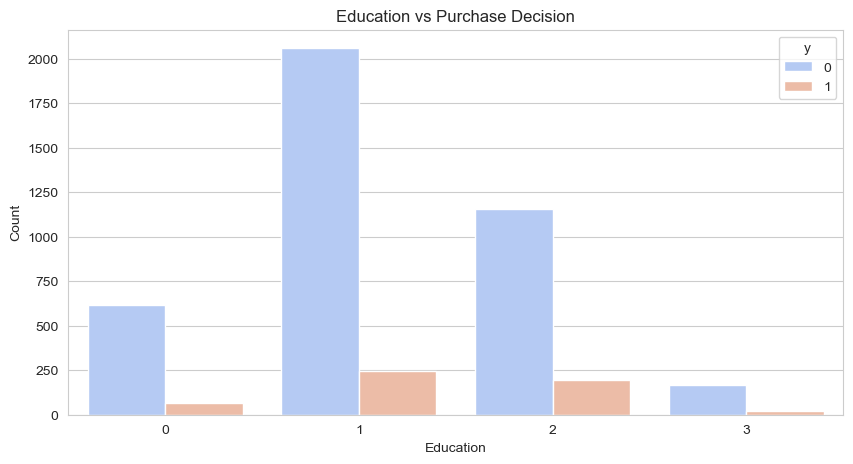

In [56]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="education",
    hue="y",
    data=df,
    palette="coolwarm"
)

plt.title("Education vs Purchase Decision")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

In [57]:
print("Conclusion:")
print("- Customers with secondary education dominate the dataset.")
print("- Subscription behavior varies across education levels.")

Conclusion:
- Customers with secondary education dominate the dataset.
- Subscription behavior varies across education levels.


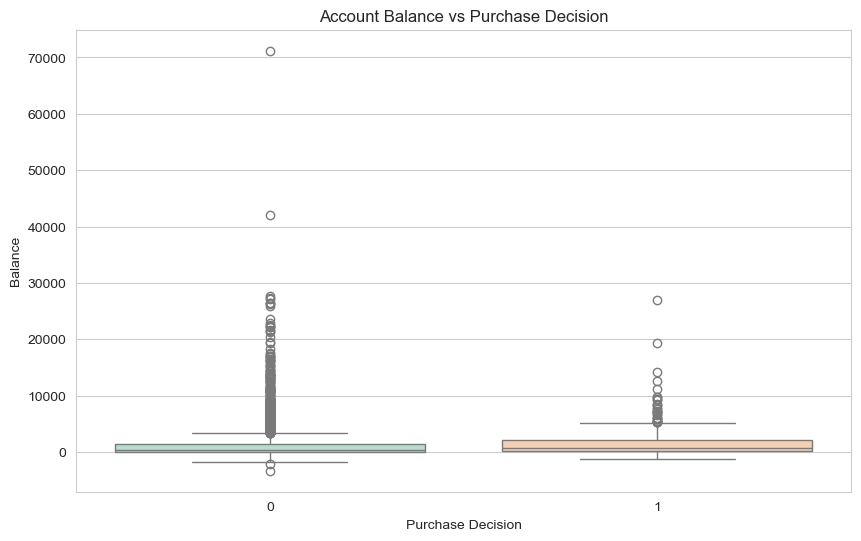

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="y",
    y="balance",
    data=df,
    palette="Pastel2"
)

plt.title("Account Balance vs Purchase Decision")
plt.xlabel("Purchase Decision")
plt.ylabel("Balance")

plt.show()

In [59]:
print("Conclusion:")
print("- Customers with higher account balances are more likely to subscribe.")
print("- The balance feature contains several outliers.")

Conclusion:
- Customers with higher account balances are more likely to subscribe.
- The balance feature contains several outliers.


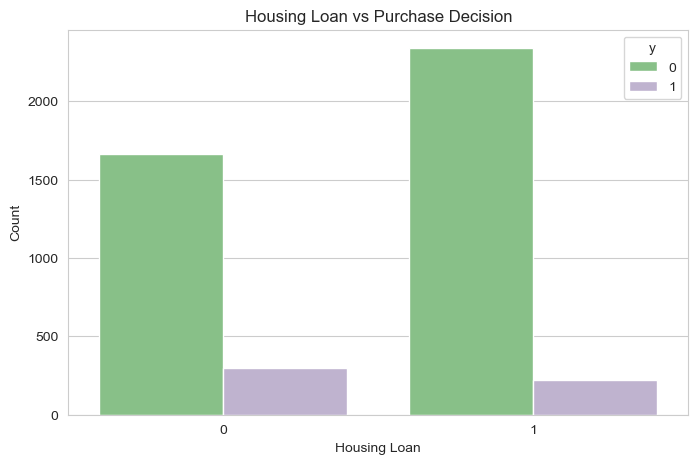

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="housing",
    hue="y",
    data=df,
    palette="Accent"
)

plt.title("Housing Loan vs Purchase Decision")
plt.xlabel("Housing Loan")
plt.ylabel("Count")

plt.show()

In [61]:
print("Conclusion:")
print("- Customers with higher account balances are more likely to subscribe.")
print("- The balance feature contains several outliers.")

Conclusion:
- Customers with higher account balances are more likely to subscribe.
- The balance feature contains several outliers.


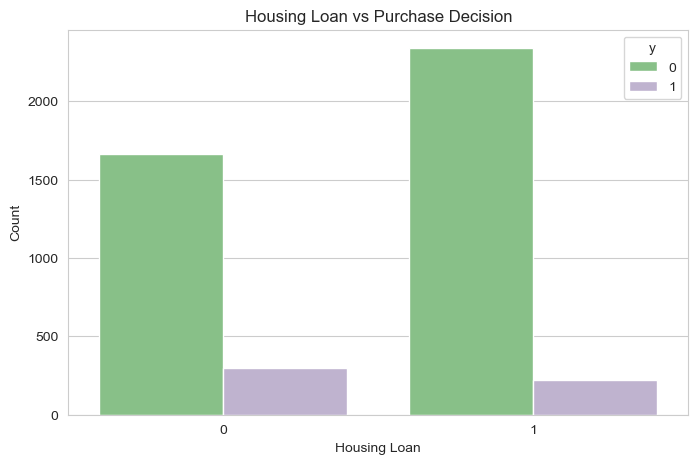

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="housing",
    hue="y",
    data=df,
    palette="Accent"
)

plt.title("Housing Loan vs Purchase Decision")
plt.xlabel("Housing Loan")
plt.ylabel("Count")

plt.show()

In [63]:
print("Conclusion:")
print("- Customers without housing loans subscribe more frequently.")

Conclusion:
- Customers without housing loans subscribe more frequently.


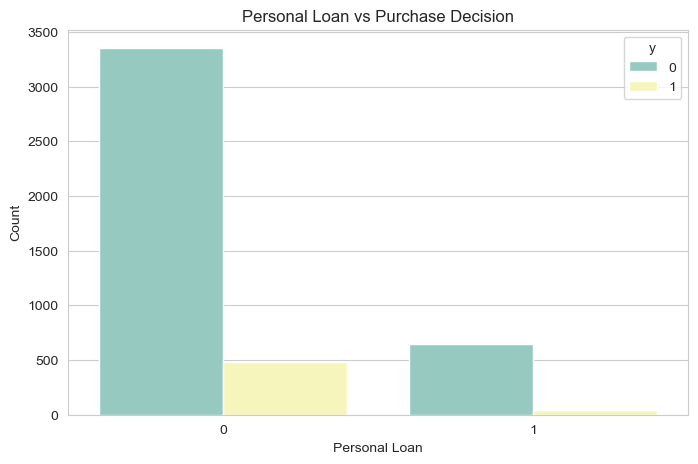

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="loan",
    hue="y",
    data=df,
    palette="Set3"
)

plt.title("Personal Loan vs Purchase Decision")
plt.xlabel("Personal Loan")
plt.ylabel("Count")

plt.show()

In [65]:
print("Conclusion:")
print("- Customers without personal loans are more likely to subscribe.")

Conclusion:
- Customers without personal loans are more likely to subscribe.


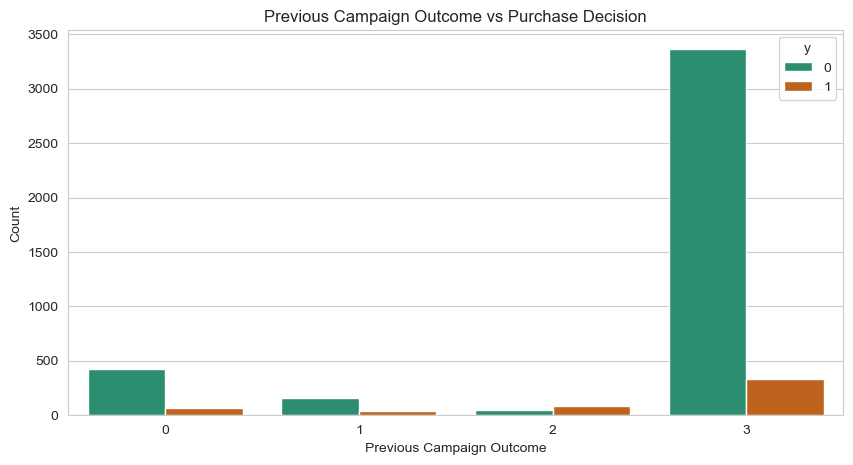

In [66]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="poutcome",
    hue="y",
    data=df,
    palette="Dark2"
)

plt.title("Previous Campaign Outcome vs Purchase Decision")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Count")

plt.show()

In [67]:
print("Conclusion:")
print("- Customers who previously had a successful campaign are much more likely to subscribe again.")

Conclusion:
- Customers who previously had a successful campaign are much more likely to subscribe again.


# Correlation Heatmap

The heatmap helps identify relationships among numerical variables.

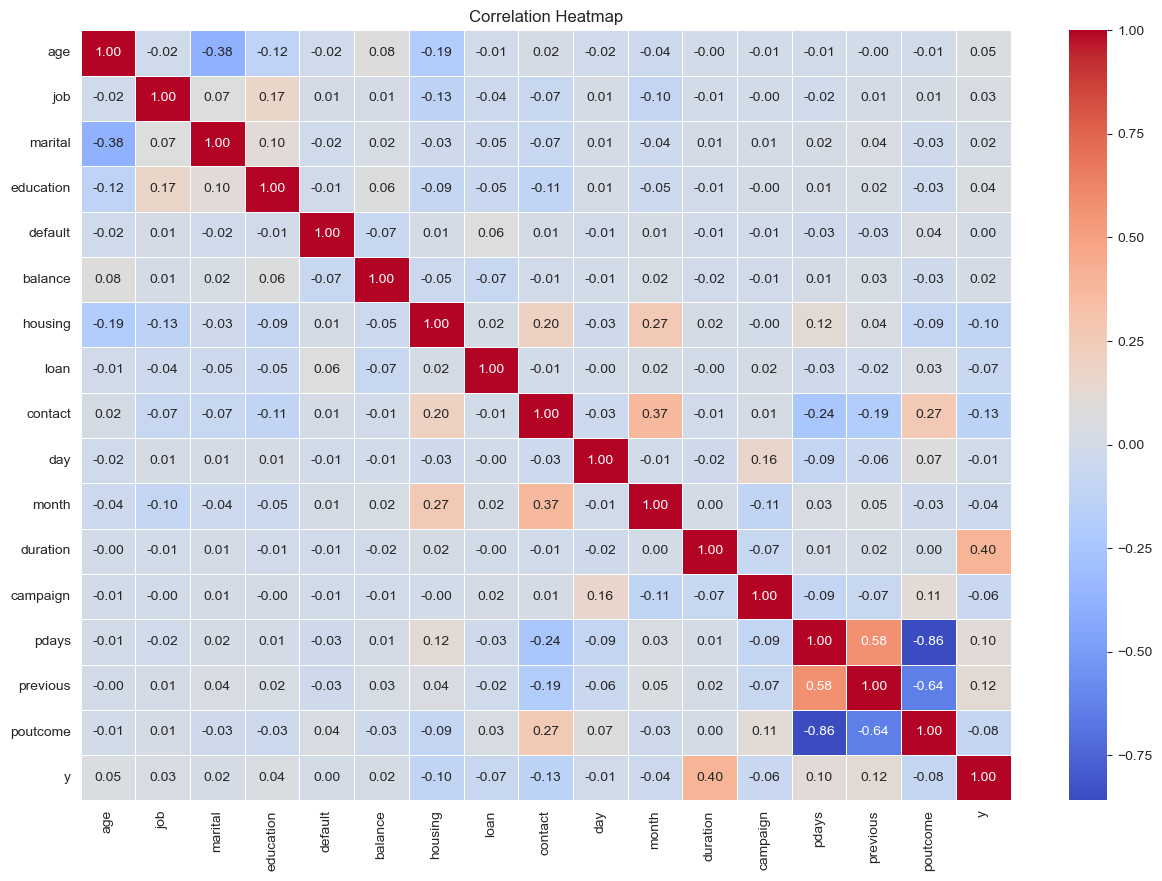

In [69]:
plt.figure(figsize=(15,10))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [70]:
print("Conclusion:")
print("- Most features have weak linear correlations.")
print("- Duration generally has one of the strongest positive relationships with the target.")
print("- Previous campaign outcome also contributes to subscription prediction.")

Conclusion:
- Most features have weak linear correlations.
- Duration generally has one of the strongest positive relationships with the target.
- Previous campaign outcome also contributes to subscription prediction.


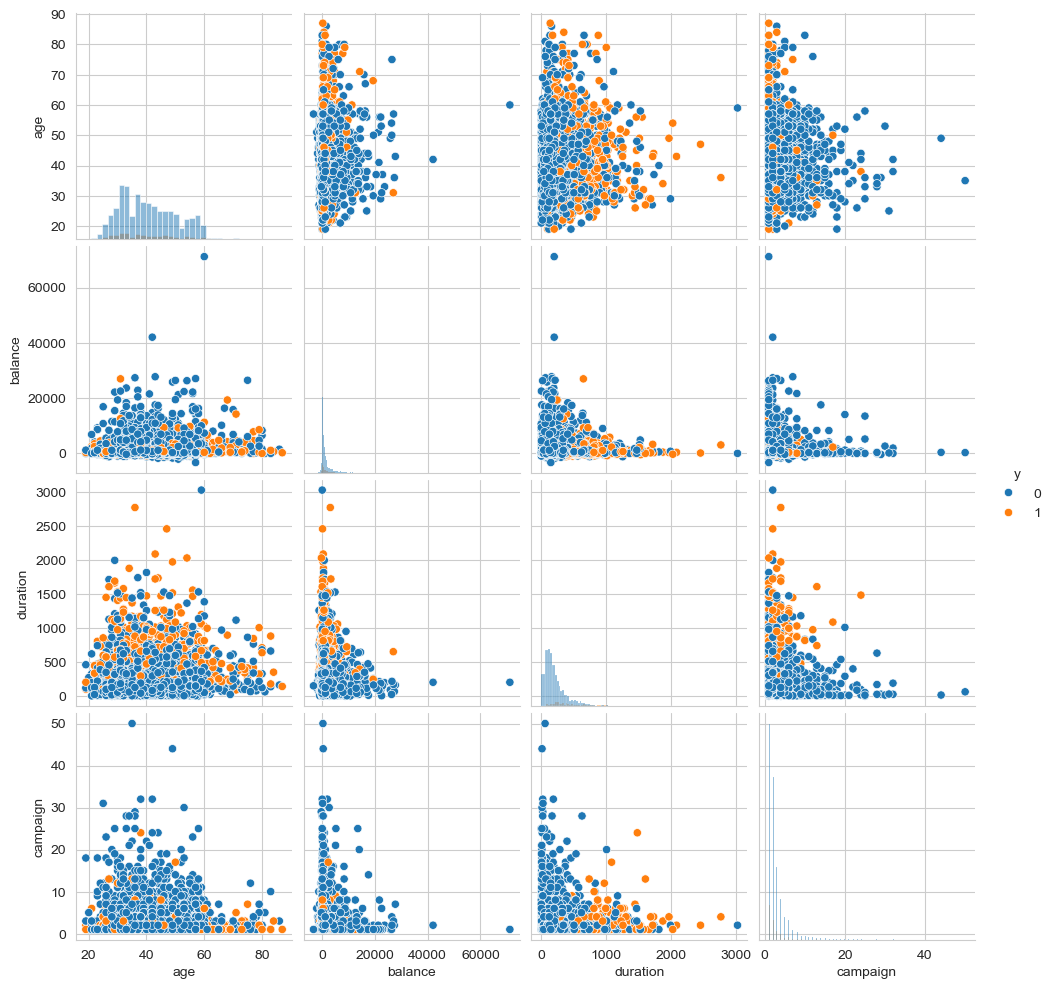

In [71]:
pair_columns = ["age", "balance", "duration", "campaign", "y"]

sns.pairplot(
    df[pair_columns],
    hue="y",
    diag_kind="hist"
)

plt.show()

In [72]:
print("Conclusion:")
print("- Customers with longer call durations are more likely to subscribe.")
print("- No strong linear relationship exists between age and balance.")

Conclusion:
- Customers with longer call durations are more likely to subscribe.
- No strong linear relationship exists between age and balance.


In [73]:
print("=" * 70)
print("BIVARIATE ANALYSIS SUMMARY")
print("=" * 70)

print("""
1. Older customers show a slightly higher subscription tendency.
2. Management and technician occupations contribute many subscriptions.
3. Single customers have a relatively better subscription rate.
4. Higher account balances are associated with increased subscriptions.
5. Customers without housing or personal loans subscribe more often.
6. Previous successful campaign outcomes strongly influence future subscriptions.
7. Call duration appears to be one of the strongest predictors of customer response.
8. Most numerical features exhibit weak linear correlations, indicating the need for non-linear models such as Decision Trees.
""")

BIVARIATE ANALYSIS SUMMARY

1. Older customers show a slightly higher subscription tendency.
2. Management and technician occupations contribute many subscriptions.
3. Single customers have a relatively better subscription rate.
4. Higher account balances are associated with increased subscriptions.
5. Customers without housing or personal loans subscribe more often.
6. Previous successful campaign outcomes strongly influence future subscriptions.
7. Call duration appears to be one of the strongest predictors of customer response.
8. Most numerical features exhibit weak linear correlations, indicating the need for non-linear models such as Decision Trees.



# Feature Selection

In this section, we separate the independent variables (features)
from the dependent variable (target).

- X → Input Features
- y → Target Variable

In [74]:
# Feature Selection


# Features
X = df.drop("y", axis=1)

# Target
y = df["y"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (4521, 16)
Target Shape         : (4521,)


In [75]:
print("Feature Names\n")
print(X.columns.tolist())

Feature Names

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


# Train-Test Split

The dataset is divided into training and testing sets.

- 80% Training Data
- 20% Testing Data

In [76]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Samples : 3616
Testing Samples  : 905

Training Shape : (3616, 16)
Testing Shape  : (905, 16)


# Decision Tree Classifier

A Decision Tree Classifier learns decision rules from the training data
to classify customers into subscription or non-subscription categories.

Criterion Used:
- Entropy

In [78]:
# Build Decision Tree Model


model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


# Prediction

The trained model predicts customer subscription
on the testing dataset.

In [80]:
# Prediction


y_pred = model.predict(X_test)

print("Prediction Completed Successfully!\n")

Prediction Completed Successfully!



In [81]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(15)

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# Model Evaluation

The model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

In [82]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score")
print("----------------")
print(round(accuracy * 100, 2), "%")

Accuracy Score
----------------
85.41 %


In [83]:
precision = precision_score(y_test, y_pred)

print("Precision Score")
print("----------------")
print(round(precision, 4))

Precision Score
----------------
0.3534


In [84]:
recall = recall_score(y_test, y_pred)

print("Recall Score")
print("----------------")
print(round(recall, 4))

Recall Score
----------------
0.4184


In [85]:
f1 = f1_score(y_test, y_pred)

print("F1 Score")
print("----------------")
print(round(f1, 4))

F1 Score
----------------
0.3832


In [86]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics

,Metric,Value
0,Accuracy,0.854144
1,Precision,0.353448
2,Recall,0.418367
3,F1 Score,0.383178


In [87]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[732  75]
 [ 57  41]]


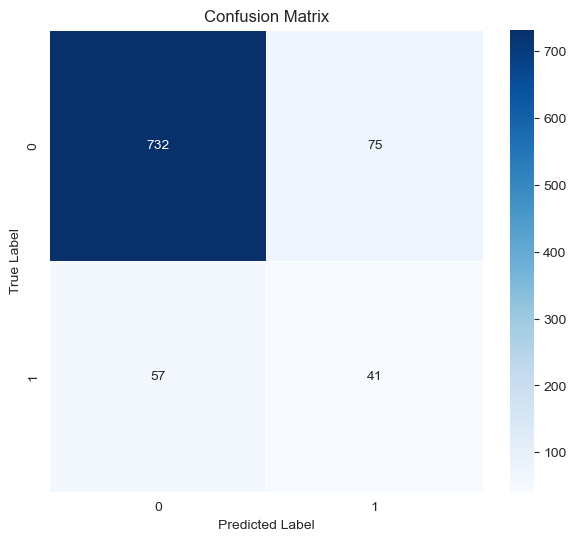

In [88]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    linewidths=0.5
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [89]:
print("Conclusion:")
print("- The diagonal values represent correct predictions.")
print("- Off-diagonal values represent incorrect predictions.")
print("- Higher diagonal values indicate better model performance.")

Conclusion:
- The diagonal values represent correct predictions.
- Off-diagonal values represent incorrect predictions.
- Higher diagonal values indicate better model performance.


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       807
           1       0.35      0.42      0.38        98

    accuracy                           0.85       905
   macro avg       0.64      0.66      0.65       905
weighted avg       0.87      0.85      0.86       905



In [91]:
print("Classification Report Interpretation")

print("-------------------------------------")

print("Precision:")
print("Measures how many predicted positives were actually correct.\n")

print("Recall:")
print("Measures how many actual positives were correctly identified.\n")

print("F1 Score:")
print("Harmonic mean of Precision and Recall.\n")

print("Support:")
print("Number of samples in each class.\n")

Classification Report Interpretation
-------------------------------------
Precision:
Measures how many predicted positives were actually correct.

Recall:
Measures how many actual positives were correctly identified.

F1 Score:
Harmonic mean of Precision and Recall.

Support:
Number of samples in each class.



In [92]:
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MODEL PERFORMANCE SUMMARY
Accuracy  : 0.8541
Precision : 0.3534
Recall    : 0.4184
F1 Score  : 0.3832


In [93]:
print("\nBusiness Insights")
print("-------------------------------")

print("1. The Decision Tree successfully classifies customers into subscription and non-subscription groups.")
print("2. Accuracy measures the overall correctness of predictions.")
print("3. Precision indicates the reliability of positive predictions.")
print("4. Recall shows the model's ability to identify actual subscribers.")
print("5. F1 Score provides a balanced evaluation of Precision and Recall.")
print("6. The model can support marketing teams in identifying customers who are more likely to subscribe.")


Business Insights
-------------------------------
1. The Decision Tree successfully classifies customers into subscription and non-subscription groups.
2. Accuracy measures the overall correctness of predictions.
3. Precision indicates the reliability of positive predictions.
4. Recall shows the model's ability to identify actual subscribers.
5. F1 Score provides a balanced evaluation of Precision and Recall.
6. The model can support marketing teams in identifying customers who are more likely to subscribe.


# Decision Tree Visualization

A Decision Tree is a supervised machine learning algorithm that makes
predictions by splitting the dataset into smaller subsets based on the
most informative features.

Each internal node represents a decision,
each branch represents the outcome of the decision,
and each leaf node represents the final prediction.

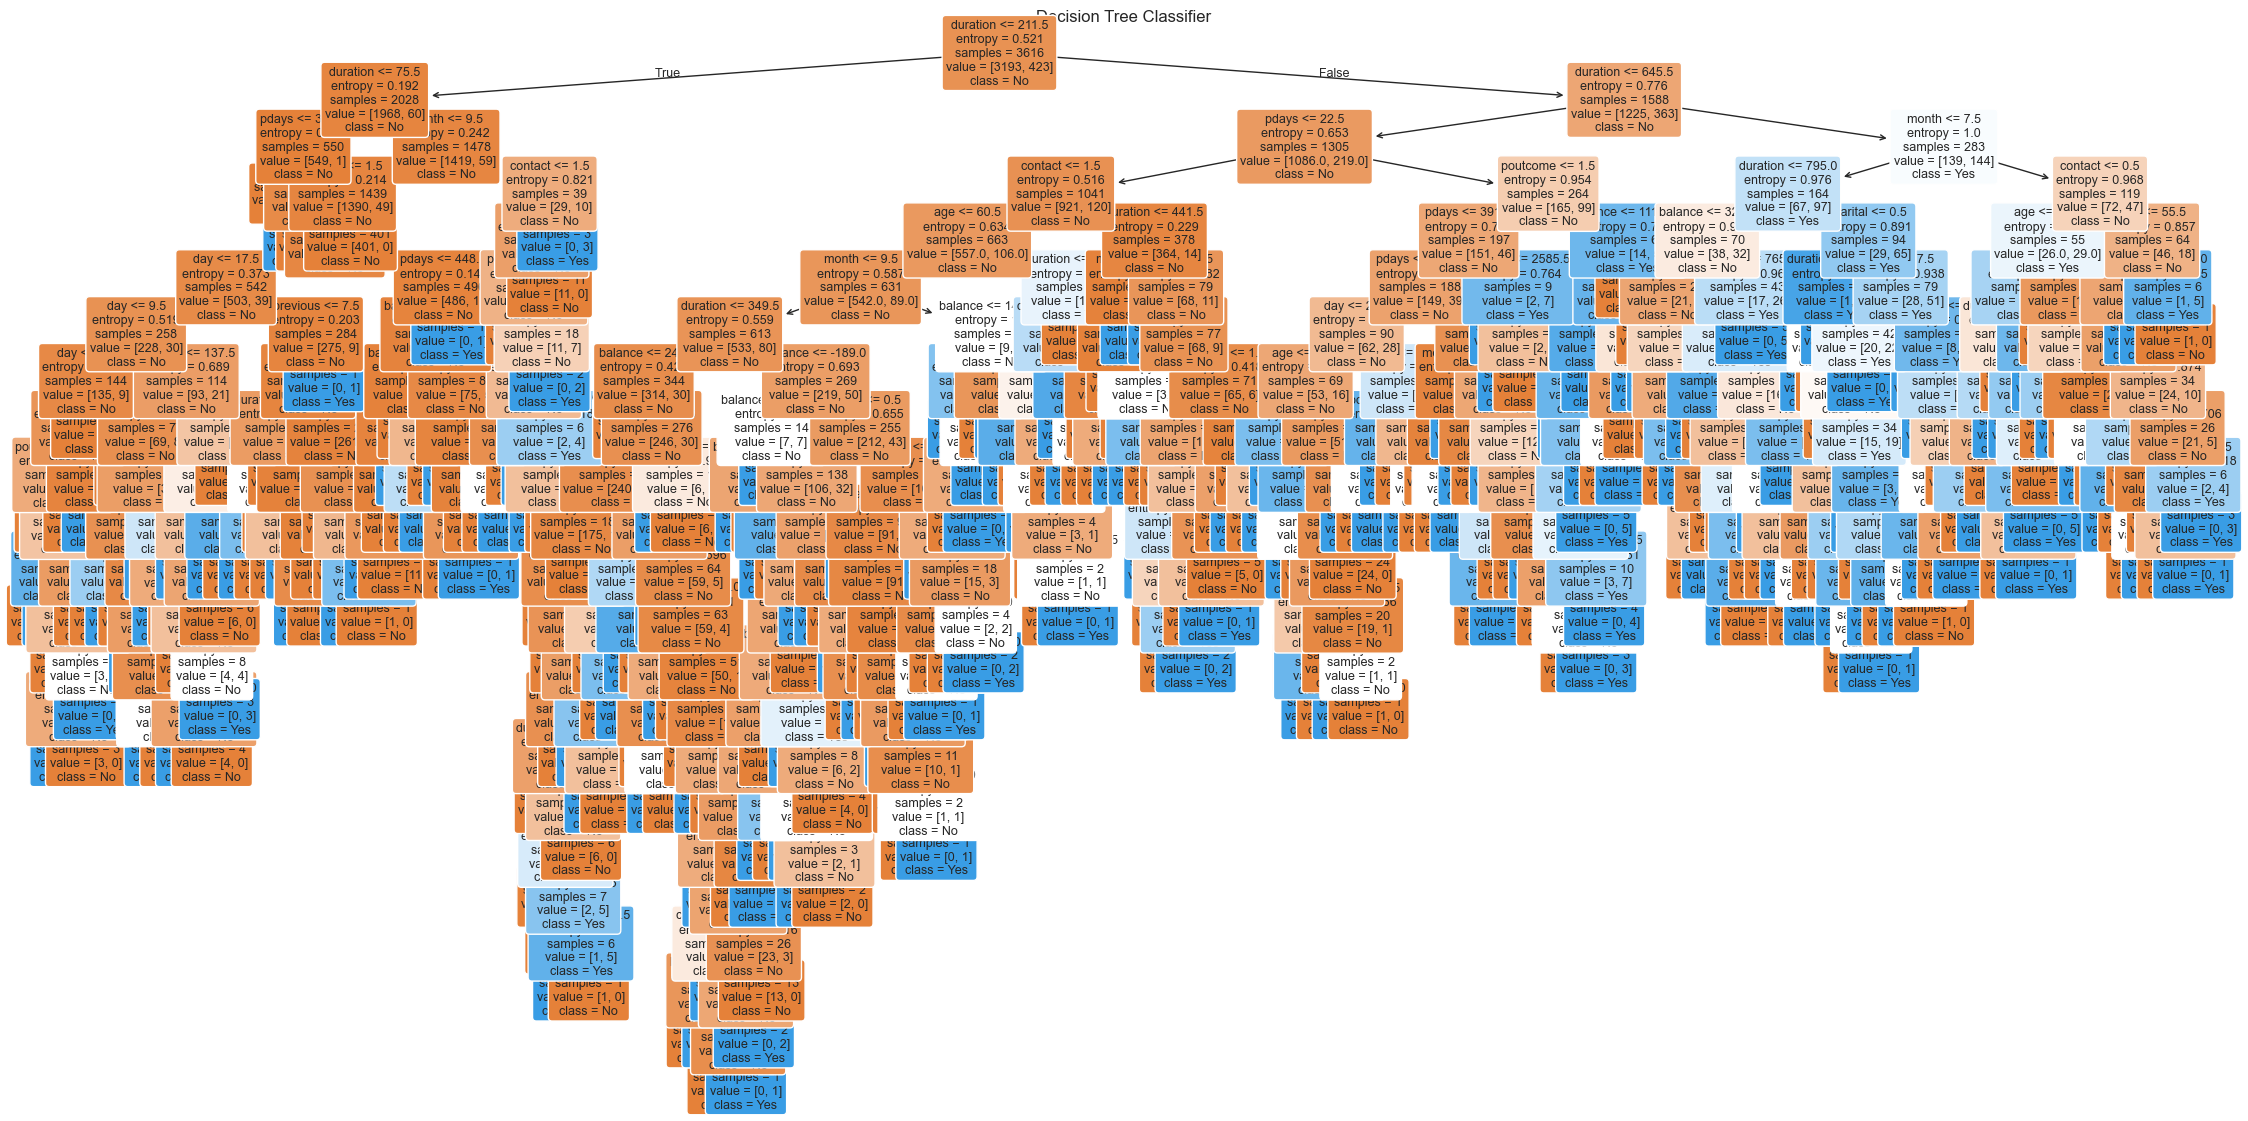

In [94]:
# Decision Tree Visualization


plt.figure(figsize=(28, 14))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier")

plt.show()

In [95]:
print("Conclusion:")
print("- The root node contains the feature that provides the highest information gain.")
print("- Each split divides the data into more homogeneous groups.")
print("- Leaf nodes represent the final prediction (Subscribe or Not Subscribe).")
print("- Decision Trees are easy to understand and interpret.")

Conclusion:
- The root node contains the feature that provides the highest information gain.
- Each split divides the data into more homogeneous groups.
- Leaf nodes represent the final prediction (Subscribe or Not Subscribe).
- Decision Trees are easy to understand and interpret.


# Feature Importance

Decision Trees assign an importance score to every feature.

Higher importance means the feature contributes more
towards making predictions.

In [96]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
11,duration,0.303261
5,balance,0.100952
10,month,0.094587
0,age,0.090966
9,day,0.085821
13,pdays,0.072370
12,campaign,0.049514
8,contact,0.044123
1,job,0.040302
15,poutcome,0.039799


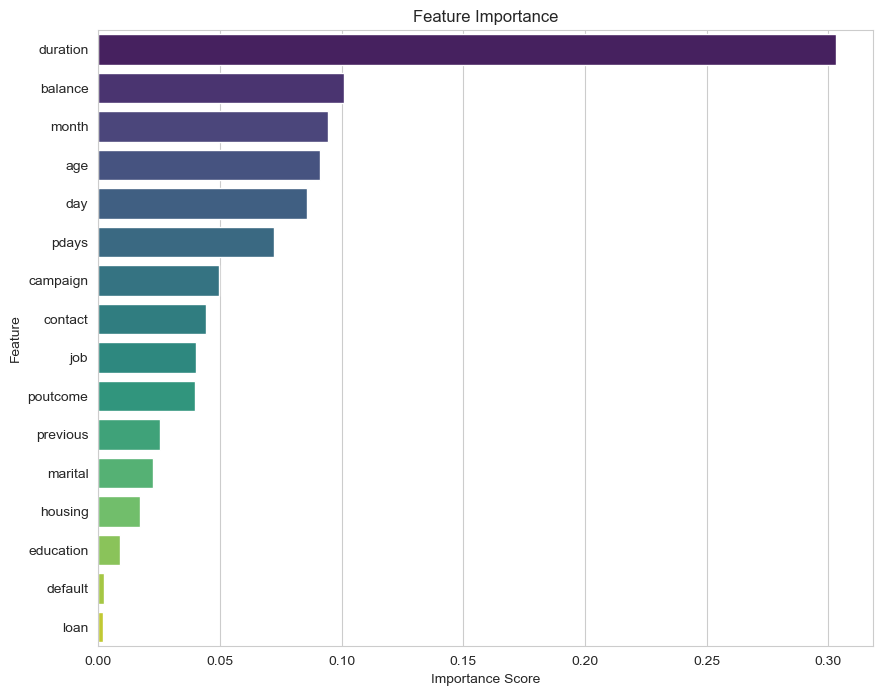

In [97]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

In [98]:
print("Conclusion:")
print("- Features with higher importance contribute more to customer subscription prediction.")
print("- Duration, previous campaign outcome, balance, and age often rank among the most influential features.")
print("- Less important features have minimal impact on the Decision Tree.")

Conclusion:
- Features with higher importance contribute more to customer subscription prediction.
- Duration, previous campaign outcome, balance, and age often rank among the most influential features.
- Less important features have minimal impact on the Decision Tree.


# Save the Cleaned Dataset

The cleaned dataset is saved so that it can be reused
without repeating preprocessing steps.

In [99]:
# Save Dataset


df.to_csv("cleaned_bank.csv", index=False)

print("Cleaned dataset saved successfully!")

print("File Name : cleaned_bank.csv")

Cleaned dataset saved successfully!
File Name : cleaned_bank.csv


# Final Summary

This section summarizes all preprocessing,
exploratory analysis, and model building steps.

In [102]:
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"Original Dataset Shape : {original_shape}")
print(f"Cleaned Dataset Shape  : {df.shape}")

print()

print(f"Missing Values Handled : {missing_values.sum()}")

print(f"Duplicate Records Removed : {duplicates}")

print()

print(f"Model Accuracy : {accuracy:.4f}")

print(f"Precision      : {precision:.4f}")

print(f"Recall         : {recall:.4f}")

print(f"F1 Score       : {f1:.4f}")

print()

print("Top Important Features:")

print(importance.head(10))

print("=" * 70)

FINAL PROJECT SUMMARY
Original Dataset Shape : (4521, 17)
Cleaned Dataset Shape  : (4521, 17)

Missing Values Handled : 0
Duplicate Records Removed : 0

Model Accuracy : 0.8541
Precision      : 0.3534
Recall         : 0.4184
F1 Score       : 0.3832

Top Important Features:
     Feature  Importance
11  duration    0.303261
5    balance    0.100952
10     month    0.094587
0        age    0.090966
9        day    0.085821
13     pdays    0.072370
12  campaign    0.049514
8    contact    0.044123
1        job    0.040302
15  poutcome    0.039799


In [101]:
original_shape = df.shape

In [103]:
print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. Customer age influences purchasing behaviour but is not the strongest predictor.

2. Customers with successful previous marketing campaigns are
more likely to subscribe again.

3. Longer call duration generally indicates a higher probability
of subscription.

4. Customers without housing or personal loans tend to subscribe
more frequently.

5. Account balance has a positive influence on customer response.

6. Decision Tree models provide interpretable decision rules that
help marketing teams understand customer behaviour.

7. Feature importance analysis identifies the variables that most
strongly influence purchasing decisions.

8. These insights can help banks target potential customers more
effectively and improve marketing campaign success.
""")

BUSINESS INSIGHTS

1. Customer age influences purchasing behaviour but is not the strongest predictor.

2. Customers with successful previous marketing campaigns are
more likely to subscribe again.

3. Longer call duration generally indicates a higher probability
of subscription.

4. Customers without housing or personal loans tend to subscribe
more frequently.

5. Account balance has a positive influence on customer response.

6. Decision Tree models provide interpretable decision rules that
help marketing teams understand customer behaviour.

7. Feature importance analysis identifies the variables that most
strongly influence purchasing decisions.

8. These insights can help banks target potential customers more
effectively and improve marketing campaign success.



In [104]:
print("=" * 70)
print("PROJECT CONCLUSION")
print("=" * 70)

print("""
The Bank Marketing dataset was successfully analyzed using
Data Cleaning, Exploratory Data Analysis (EDA), and a Decision Tree Classifier.

Key preprocessing steps included:
• Handling missing values
• Removing duplicate records
• Encoding categorical variables

The Decision Tree model was trained and evaluated using:
• Accuracy
• Precision
• Recall
• F1 Score
• Confusion Matrix
• Classification Report

Feature Importance identified the variables that contribute
most to predicting customer subscription.

The project demonstrates how machine learning can support
business decision-making by identifying customers who are
more likely to purchase a product or subscribe to a service.
""")

print("=" * 70)
print("TASK-03 COMPLETED SUCCESSFULLY")
print("=" * 70)

PROJECT CONCLUSION

The Bank Marketing dataset was successfully analyzed using
Data Cleaning, Exploratory Data Analysis (EDA), and a Decision Tree Classifier.

Key preprocessing steps included:
• Handling missing values
• Removing duplicate records
• Encoding categorical variables

The Decision Tree model was trained and evaluated using:
• Accuracy
• Precision
• Recall
• F1 Score
• Confusion Matrix
• Classification Report

Feature Importance identified the variables that contribute
most to predicting customer subscription.

The project demonstrates how machine learning can support
business decision-making by identifying customers who are
more likely to purchase a product or subscribe to a service.

TASK-03 COMPLETED SUCCESSFULLY
